## Deep Learning for Solar Power Forecasting and Anomaly Detection

For this assignment I chose the **Solar Power Generation Data** from Kaggle.  
The main idea is to predict solar production/yield using the weather sensor data, and then detect unusual behavior like cases where irradiation is high but generated power is unexpectedly low.

I tried to keep the notebook as straightforward as possible: first I clean and aggregate the data, then I build features, then I compare a classical DL model with a more advanced model, and finally anomaly detection.

In [1]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.ensemble import IsolationForest

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

# Reproducibility. Results can still vary a bit depending on hardware/GPU.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = "./data"
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

## 1. Dataset loading

The generation files and weather files have slightly different datetime formats.  
Plant 1 generation uses format like 15-05-2020 00:00, while the other files use 2020-05-15 00:00:00. Because of that, pd.to_datetime(..., dayfirst=True) should work to let pandas figure the format.

Also noticed that at least one sample value in the generation data can be corrupted, so I convert numeric columns using errors="coerce" and later handle missing values.

In [2]:
def load_csv(filename):
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Could not find {path}. Check that the CSV files are in ./data")
    return pd.read_csv(path)

plant1_gen = load_csv("Plant_1_Generation_Data.csv")
plant1_weather = load_csv("Plant_1_Weather_Sensor_Data.csv")
plant2_gen = load_csv("Plant_2_Generation_Data.csv")
plant2_weather = load_csv("Plant_2_Weather_Sensor_Data.csv")

print("Plant 1 generation:", plant1_gen.shape)
print("Plant 1 weather:", plant1_weather.shape)
print("Plant 2 generation:", plant2_gen.shape)
print("Plant 2 weather:", plant2_weather.shape)

plant1_gen.head()

Plant 1 generation: (68778, 7)
Plant 1 weather: (3182, 6)
Plant 2 generation: (67698, 7)
Plant 2 weather: (3259, 6)


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [3]:
def clean_generation(df, plant_name):
    df = df.copy()
    df["DATE_TIME"] = pd.to_datetime(df["DATE_TIME"], dayfirst=True, errors="coerce")
    numeric_cols = ["PLANT_ID", "DC_POWER", "AC_POWER", "DAILY_YIELD", "TOTAL_YIELD"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df["PLANT"] = plant_name
    return df


def clean_weather(df, plant_name):
    df = df.copy()
    df["DATE_TIME"] = pd.to_datetime(df["DATE_TIME"], dayfirst=True, errors="coerce")
    numeric_cols = ["PLANT_ID", "AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df["PLANT"] = plant_name
    return df

plant1_gen = clean_generation(plant1_gen, "Plant_1")
plant2_gen = clean_generation(plant2_gen, "Plant_2")
plant1_weather = clean_weather(plant1_weather, "Plant_1")
plant2_weather = clean_weather(plant2_weather, "Plant_2")

generation = pd.concat([plant1_gen, plant2_gen], ignore_index=True)
weather = pd.concat([plant1_weather, plant2_weather], ignore_index=True)

print(generation.isna().sum())
print(weather.isna().sum())

DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
PLANT          0
dtype: int64
DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
PLANT                  0
dtype: int64


## 2. Aggregating and merging the data

The generation data has multiple inverter/source rows for the same timestamp, while weather usually has one sensor row per timestamp and plant.  
For forecasting, I aggregate to one row per plant and timestamp:

- sum DC_POWER, AC_POWER, and DAILY_YIELD over inverters
- average the weather measurements

This ensures we have a cleaner time series where each timestamp is one observation per plant.

In [5]:
generation = generation.dropna(subset=["DATE_TIME"])
weather = weather.dropna(subset=["DATE_TIME"])

#handle impossible negative values
for col in ["DC_POWER", "AC_POWER", "DAILY_YIELD", "TOTAL_YIELD"]:
    generation.loc[generation[col] < 0, col] = np.nan
for col in ["AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION"]:
    weather.loc[weather[col] < 0, col] = np.nan

gen_agg = (
    generation
    .groupby(["PLANT", "DATE_TIME"], as_index=False)
    .agg({
        "DC_POWER": "sum",
        "AC_POWER": "sum",
        "DAILY_YIELD": "sum",
        "TOTAL_YIELD": "sum"
    })
)

weather_agg = (
    weather
    .groupby(["PLANT", "DATE_TIME"], as_index=False)
    .agg({
        "AMBIENT_TEMPERATURE": "mean",
        "MODULE_TEMPERATURE": "mean",
        "IRRADIATION": "mean"
    })
)

solar = pd.merge(gen_agg, weather_agg, on=["PLANT", "DATE_TIME"], how="inner")
solar = solar.sort_values(["PLANT", "DATE_TIME"]).reset_index(drop=True)

print(solar.shape)
solar.head()

(6416, 9)


,PLANT,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,Plant_1,2020-05-15 00:00:00,0.0,0.0,0.0,143581676.0,25.184316,22.857507,0.0
1,Plant_1,2020-05-15 00:15:00,0.0,0.0,0.0,143581676.0,25.084589,22.761668,0.0
2,Plant_1,2020-05-15 00:30:00,0.0,0.0,0.0,143581676.0,24.935753,22.592306,0.0
3,Plant_1,2020-05-15 00:45:00,0.0,0.0,0.0,143581676.0,24.846130,22.360852,0.0
4,Plant_1,2020-05-15 01:00:00,0.0,0.0,0.0,150761642.0,24.621525,22.165423,0.0


In [6]:
print("Date range:", solar["DATE_TIME"].min(), "to", solar["DATE_TIME"].max())
print("Plants:", solar["PLANT"].unique())
print("Missing values after merge:")
print(solar.isna().sum())

Date range: 2020-05-15 00:00:00 to 2020-06-17 23:45:00
Plants: ['Plant_1' 'Plant_2']
Missing values after merge:
PLANT                  0
DATE_TIME              0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64


## 3. Resampling

The original dataset is on 15 minute frequency. For this assignment I use hourly data.  
I chose hourly because it keeps the daily solar pattern, but makes the models faster and less noisy than using every 15 minute point.

I use:

- mean for power and weather variables
- max for daily yield, because daily yield is cumulative inside each day

In [7]:
def resample_plant(df_plant):
    df_plant = df_plant.set_index("DATE_TIME").sort_index()
    out = df_plant.resample("1H").agg({
        "DC_POWER": "mean",
        "AC_POWER": "mean",
        "DAILY_YIELD": "max",
        "TOTAL_YIELD": "max",
        "AMBIENT_TEMPERATURE": "mean",
        "MODULE_TEMPERATURE": "mean",
        "IRRADIATION": "mean"
    })
    out["PLANT"] = df_plant["PLANT"].iloc[0]
    return out

hourly = (
    solar
    .groupby("PLANT", group_keys=False)
    .apply(resample_plant)
    .reset_index()
    .rename(columns={"DATE_TIME": "datetime"})
)

#filling missing values caused by resampling. interpolation is acceptable here because the data is time ordered
hourly = hourly.sort_values(["PLANT", "datetime"])
num_cols = ["DC_POWER", "AC_POWER", "DAILY_YIELD", "TOTAL_YIELD", "AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION"]
hourly[num_cols] = hourly.groupby("PLANT")[num_cols].transform(lambda x: x.interpolate(limit_direction="both"))

hourly.head()

,datetime,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,PLANT
0,2020-05-15 00:00:00,0.0,0.0,0.0,143581676.0,25.012697,22.643083,0.0,Plant_1
1,2020-05-15 01:00:00,0.0,0.0,0.0,150761642.0,24.667328,22.411960,0.0,Plant_1
2,2020-05-15 02:00:00,0.0,0.0,0.0,143581676.0,24.986837,23.512072,0.0,Plant_1
3,2020-05-15 03:00:00,0.0,0.0,0.0,143581676.0,24.954589,24.126433,0.0,Plant_1
4,2020-05-15 04:00:00,0.0,0.0,0.0,150761642.0,24.276670,22.133106,0.0,Plant_1


## 4. Visualization and basic understanding

Before modeling, I plot the main variables. Solar production should mainly happen during the day and should be related to irradiation.  
A simple anomaly example would be: irradiation is clearly positive, but AC power is very low compared to what should be produced.

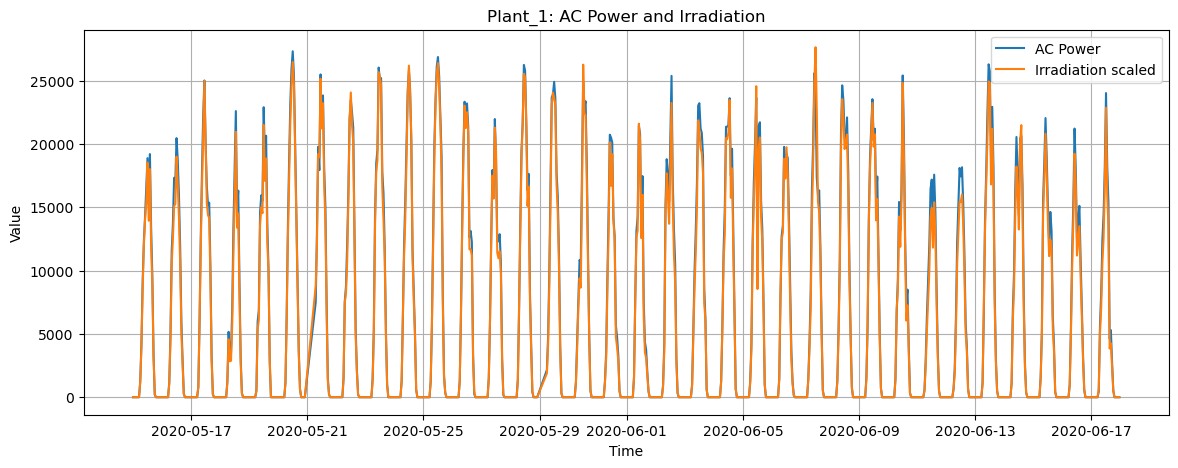

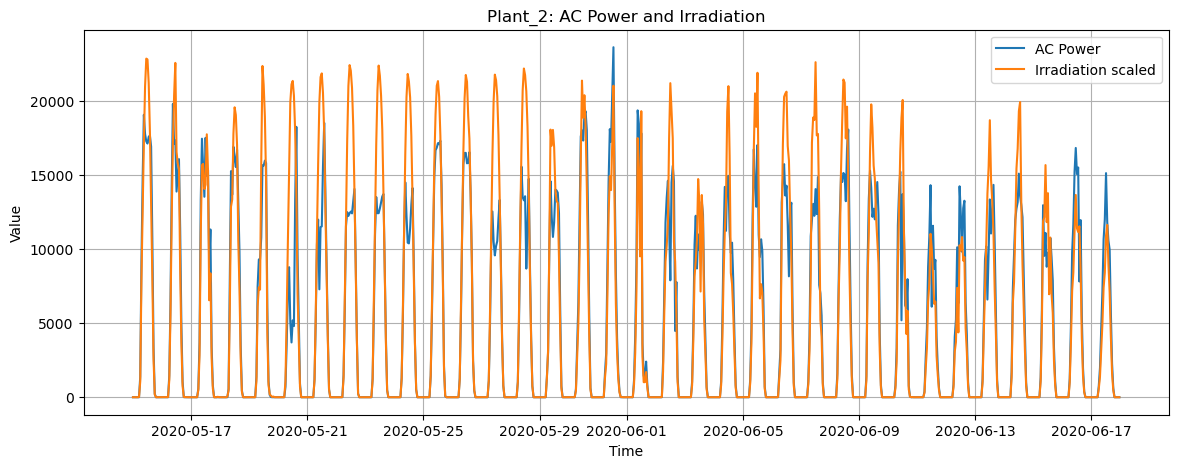

In [8]:
for plant in hourly["PLANT"].unique():
    part = hourly[hourly["PLANT"] == plant]
    plt.figure()
    plt.plot(part["datetime"], part["AC_POWER"], label="AC Power")
    plt.plot(part["datetime"], part["IRRADIATION"] * part["AC_POWER"].max(), label="Irradiation scaled")
    plt.title(f"{plant}: AC Power and Irradiation")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.show()

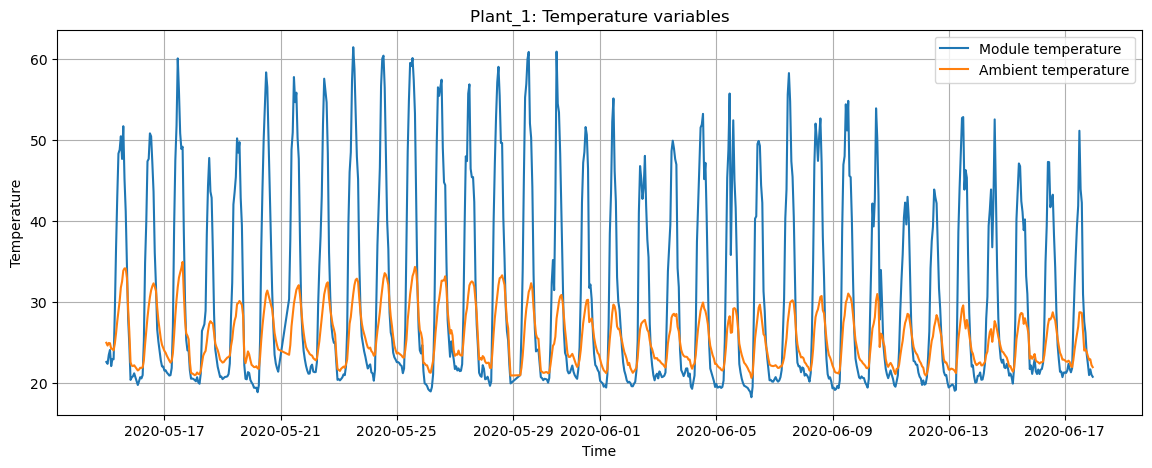

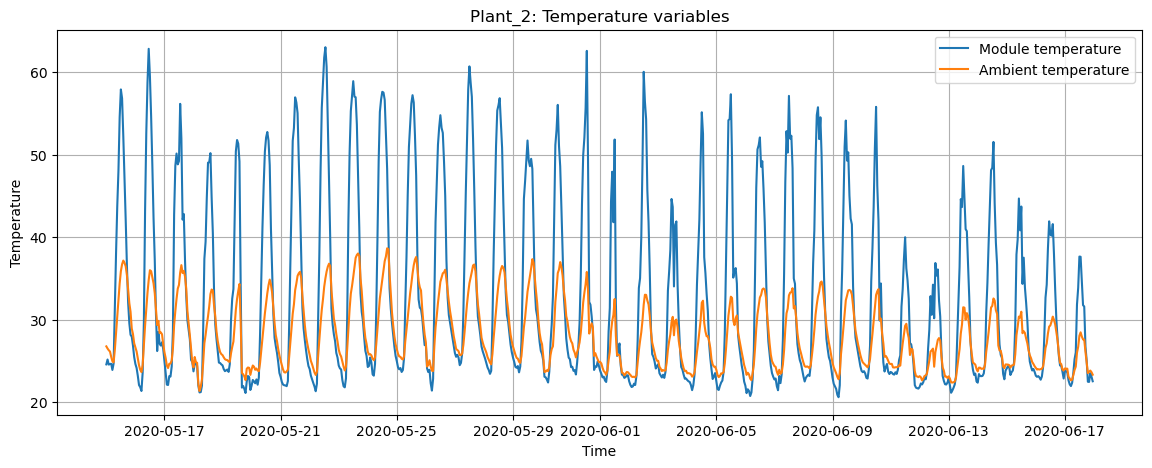

In [9]:
for plant in hourly["PLANT"].unique():
    part = hourly[hourly["PLANT"] == plant]
    plt.figure()
    plt.plot(part["datetime"], part["MODULE_TEMPERATURE"], label="Module temperature")
    plt.plot(part["datetime"], part["AMBIENT_TEMPERATURE"], label="Ambient temperature")
    plt.title(f"{plant}: Temperature variables")
    plt.xlabel("Time")
    plt.ylabel("Temperature")
    plt.legend()
    plt.show()

### Interpretation

From the plots, we see that AC power generation follows a very strong daily seasonal pattern for both plants. Power production increases during daytime, reaches a peak around midday when solar irradiation is highest, and drops close to zero during nighttime. The irradiation curve has almost the same shape as the AC power curve, showing a strong positive relationship between sunlight intensity and generated power.

The temperature plots also show clear daily cycles. Module temperature increases much more rapidly than ambient temperature during periods of high solar exposure. This is expected because solar panels heat up directly under sunlight. In both plants, module temperatures seem to frequently exceed 50°C while ambient temperature remains significantly lower.

Some irregularities can also be seen, especially in Plant 2, where some days show lower power output despite relatively high irradiation. These points may indicate temporary efficiency loss, panel degradation, weather effects, or sensor anomalies, which makes the dataset a good candidate for anomaly detection tasks.

## 5. Feature engineering

We forecast AC_POWER, because it is the useful output power after conversion.  
Add:

- time features: hour, day of week, month
- cyclic hour encoding using sine/cosine, because hour 23 and hour 0 are close in time
- lag features for previous AC power and irradiation
- rolling mean/std for recent behavior

We keep both plants in the dataset and add a simple plant id encoding

In [10]:
df = hourly.copy()
df = df.sort_values(["PLANT", "datetime"]).reset_index(drop=True)

df["target"] = df["AC_POWER"]

df["hour"] = df["datetime"].dt.hour
df["dayofweek"] = df["datetime"].dt.dayofweek
df["month"] = df["datetime"].dt.month
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["plant_id_encoded"] = df["PLANT"].map({"Plant_1": 0, "Plant_2": 1})

#lag and rolling features per plant, so we do not leak information between plants
for lag in [1, 2, 3, 6, 12, 24]:
    df[f"AC_POWER_lag_{lag}"] = df.groupby("PLANT")["AC_POWER"].shift(lag)
    df[f"IRRADIATION_lag_{lag}"] = df.groupby("PLANT")["IRRADIATION"].shift(lag)

for window in [3, 6, 12, 24]:
    df[f"AC_POWER_roll_mean_{window}"] = df.groupby("PLANT")["AC_POWER"].shift(1).rolling(window).mean().reset_index(level=0, drop=True)
    df[f"AC_POWER_roll_std_{window}"] = df.groupby("PLANT")["AC_POWER"].shift(1).rolling(window).std().reset_index(level=0, drop=True)
    df[f"IRRADIATION_roll_mean_{window}"] = df.groupby("PLANT")["IRRADIATION"].shift(1).rolling(window).mean().reset_index(level=0, drop=True)

#cleanup rows where lag features are missing
df = df.dropna().reset_index(drop=True)

feature_cols = [
    "DC_POWER", "DAILY_YIELD", "AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION",
    "hour", "dayofweek", "month", "is_weekend", "hour_sin", "hour_cos", "plant_id_encoded"
] + [c for c in df.columns if "lag_" in c or "roll_" in c]

print("Number of rows:", len(df))
print("Number of features:", len(feature_cols))
df[["datetime", "PLANT", "target"] + feature_cols[:5]].head()

Number of rows: 1584
Number of features: 36


,datetime,PLANT,target,DC_POWER,DAILY_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-16 00:00:00,Plant_1,0.0,0.0,58308.666667,22.022118,20.761620,0.0
1,2020-05-16 01:00:00,Plant_1,0.0,0.0,29154.333333,21.808217,20.281924,0.0
2,2020-05-16 02:00:00,Plant_1,0.0,0.0,0.000000,21.594317,19.802227,0.0
3,2020-05-16 03:00:00,Plant_1,0.0,0.0,0.000000,21.707953,20.258786,0.0
4,2020-05-16 04:00:00,Plant_1,0.0,0.0,0.000000,21.928550,20.762248,0.0


## 6. Train / validation / test split

For time series we do not shuffle randomly, because that would leak future information into the past.  
Instead sort by datetime and use:

- first 70% for training
- next 15% for validation
- last 15% for testing

We also scale the features using only the train data, then apply the same scaler to validation and test, so not to fall into another leakage trap

In [11]:
# global sort by time, as both plants share timestamps, should keep a realistic time based split
df = df.sort_values("datetime").reset_index(drop=True)

n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_raw = train_df[feature_cols].values
X_val_raw = val_df[feature_cols].values
X_test_raw = test_df[feature_cols].values

y_train_raw = train_df[["target"]].values
y_val_raw = val_df[["target"]].values
y_test_raw = test_df[["target"]].values

X_train_scaled = x_scaler.fit_transform(X_train_raw)
X_val_scaled = x_scaler.transform(X_val_raw)
X_test_scaled = x_scaler.transform(X_test_raw)

y_train_scaled = y_scaler.fit_transform(y_train_raw)
y_val_scaled = y_scaler.transform(y_val_raw)
y_test_scaled = y_scaler.transform(y_test_raw)

print(X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

(1108, 36) (238, 36) (238, 36)


## 7. Sequence preparation

Deep learning sequence models need a 3D input: (samples, time_steps, features)
We use the previous 24 hours to predict the next hour of AC power

This is a one step ahead forecast, but the same idea can be extended to multi step forecasting.

In [12]:
def make_sequences(X, y, window_size=24):
    X_seq, y_seq = [], []
    for i in range(window_size, len(X)):
        X_seq.append(X[i-window_size:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

WINDOW_SIZE = 24

X_train_seq, y_train_seq = make_sequences(X_train_scaled, y_train_scaled, WINDOW_SIZE)
X_val_seq, y_val_seq = make_sequences(X_val_scaled, y_val_scaled, WINDOW_SIZE)
X_test_seq, y_test_seq = make_sequences(X_test_scaled, y_test_scaled, WINDOW_SIZE)

print("Train sequences:", X_train_seq.shape, y_train_seq.shape)
print("Validation sequences:", X_val_seq.shape, y_val_seq.shape)
print("Test sequences:", X_test_seq.shape, y_test_seq.shape)

Train sequences: (1084, 24, 36) (1084, 1)
Validation sequences: (214, 24, 36) (214, 1)
Test sequences: (214, 24, 36) (214, 1)


In [13]:
def inverse_y(y_scaled):
    return y_scaler.inverse_transform(np.asarray(y_scaled).reshape(-1, 1)).ravel()


def regression_metrics(y_true, y_pred, name="model"):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE can explode near zero, so I compute it only where actual power is not almost zero.
    mask = np.abs(y_true) > 1e-3
    mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100 if mask.sum() > 0 else np.nan
    return pd.DataFrame({"Model": [name], "MAE": [mae], "RMSE": [rmse], "MAPE (%)": [mape]})


def plot_history(history, title):
    plt.figure()
    plt.plot(history.history["loss"], label="train loss")
    plt.plot(history.history["val_loss"], label="validation loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.legend()
    plt.show()


def plot_predictions(y_true, y_pred, title, max_points=250):
    plt.figure()
    plt.plot(y_true[:max_points], label="Actual")
    plt.plot(y_pred[:max_points], label="Predicted")
    plt.title(title)
    plt.xlabel("Test time step")
    plt.ylabel("AC Power")
    plt.legend()
    plt.show()

## 8. Classical deep learning forecasting model: LSTM

For the classical model I'll use an LSTM.  
LSTM is a common baseline for time series because it can learn temporal dependencies over the input window.

Also will do a small time series cross validation / hyperparameter search. I keep it small because the dataset is not huge and the assignment is more about the full workflow than about spending hours tuning.

In [14]:
def build_lstm(input_shape, units=64, dropout=0.2, lr=0.001):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(units, return_sequences=False),
        layers.Dropout(dropout),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss="mse")
    return model

#small hyperparameter search using time series splits inside the training data
param_grid = [
    {"units": 32, "dropout": 0.1, "lr": 0.001},
    {"units": 64, "dropout": 0.2, "lr": 0.001},
]

tscv = TimeSeriesSplit(n_splits=3)
cv_results = []

#to make CV faster, I run fewer epochs here
for params in param_grid:
    fold_losses = []
    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_train_scaled), start=1):
        X_tr_raw, X_va_raw = X_train_scaled[tr_idx], X_train_scaled[va_idx]
        y_tr_raw, y_va_raw = y_train_scaled[tr_idx], y_train_scaled[va_idx]
        if len(X_tr_raw) <= WINDOW_SIZE or len(X_va_raw) <= WINDOW_SIZE:
            continue
        X_tr, y_tr = make_sequences(X_tr_raw, y_tr_raw, WINDOW_SIZE)
        X_va, y_va = make_sequences(X_va_raw, y_va_raw, WINDOW_SIZE)
        model = build_lstm(X_tr.shape[1:], **params)
        es = callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
        hist = model.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=15, batch_size=32, verbose=0, callbacks=[es])
        fold_losses.append(min(hist.history["val_loss"]))
    cv_results.append({**params, "mean_val_loss": np.mean(fold_losses)})

cv_results_df = pd.DataFrame(cv_results).sort_values("mean_val_loss")
cv_results_df

,units,dropout,lr,mean_val_loss
0,32,0.1,0.001,0.144020
1,64,0.2,0.001,0.145917


We see the smaller model with 32 units and 0.1 dropout performed slightly better so this one will be chosen

Best LSTM params: {'units': 32, 'dropout': 0.1, 'lr': 0.001}
Epoch 1/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.3956 - val_loss: 0.1508
Epoch 2/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1611 - val_loss: 0.1319
Epoch 3/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1484 - val_loss: 0.1301
Epoch 4/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1335 - val_loss: 0.1272
Epoch 5/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1204 - val_loss: 0.1353
Epoch 6/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1237 - val_loss: 0.1390
Epoch 7/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1249 - val_loss: 0.1546
Epoch 8/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1189 - val_loss: 0.1379
Epoch 9/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1201 - val_loss: 0.1381
Epoch 10/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1146 - val_loss: 0.1497
Epoch 11/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1157 - val_loss: 0.1522
Epoch 12/60


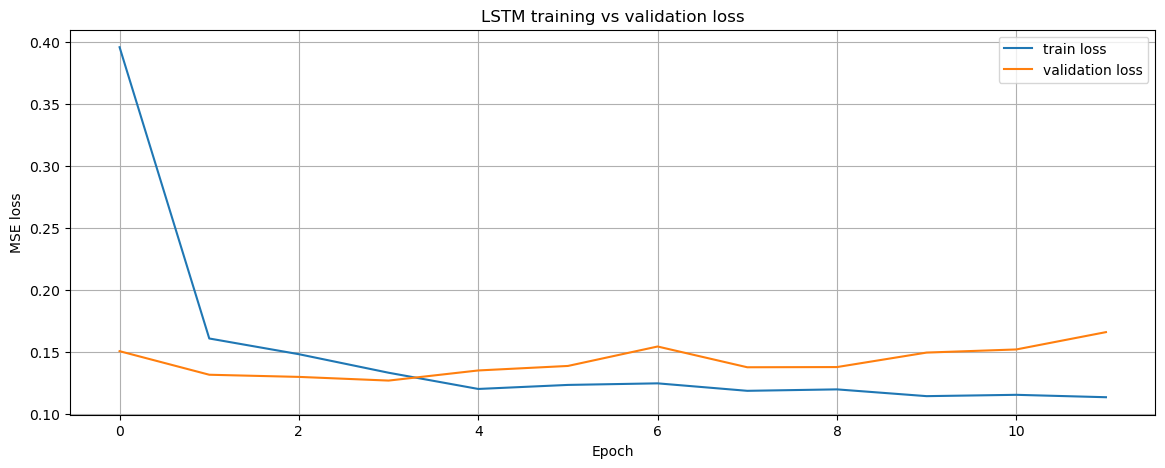

In [15]:
best_lstm_params = cv_results_df.iloc[0][["units", "dropout", "lr"]].to_dict()
best_lstm_params["units"] = int(best_lstm_params["units"])
print("Best LSTM params:", best_lstm_params)

lstm_model = build_lstm(X_train_seq.shape[1:], **best_lstm_params)
es = callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

lstm_history = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=60,
    batch_size=32,
    verbose=1,
    callbacks=[es]
)

plot_history(lstm_history, "LSTM training vs validation loss")

We can see it's not much but some mild overfitting is beginning to develop here after around epoch 4

In [16]:
lstm_pred_scaled = lstm_model.predict(X_test_seq).ravel()
lstm_pred = inverse_y(lstm_pred_scaled)
y_test_true = inverse_y(y_test_seq)

lstm_metrics = regression_metrics(y_test_true, lstm_pred, "LSTM")
lstm_metrics

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


,Model,MAE,RMSE,MAPE (%)
0,LSTM,1489.158346,2377.82248,42.572299


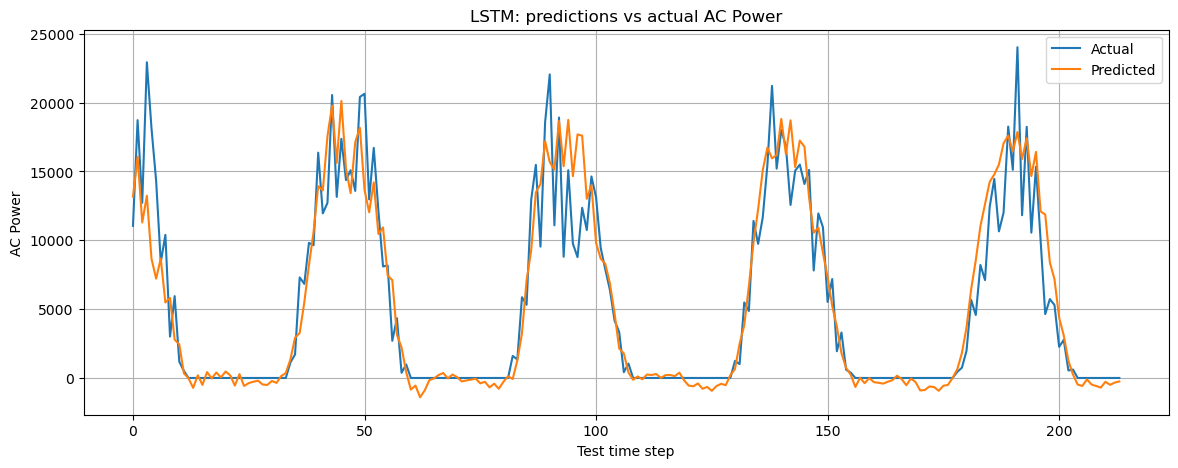

In [17]:
plot_predictions(y_test_true, lstm_pred, "LSTM: predictions vs actual AC Power")

## 9. Advanced deep learning forecasting model: TCN

For the advanced model we use a Temporal Convolutional Network (TCN) style architecture.  
The reason for this is that TCNs can model sequence history with causal/dilated convolutions. Compared with LSTM, they are often faster to train because convolutions are easier to parallelize.

Will implement a compact TCN manually with Conv1D layers

Epoch 1/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.3967 - val_loss: 0.2023
Epoch 2/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1740 - val_loss: 0.2009
Epoch 3/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1530 - val_loss: 0.1945
Epoch 4/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1494 - val_loss: 0.2192
Epoch 5/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1458 - val_loss: 0.2225
Epoch 6/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1423 - val_loss: 0.2316
Epoch 7/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1386 - val_loss: 0.2356
Epoch 8/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1360 - val_loss: 0.2330
Epoch 9/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1372 - val_loss: 0.2253
Epoch 10/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1346 - val_loss: 0.2437
Epoch 11/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1291 - val_loss: 0.2494


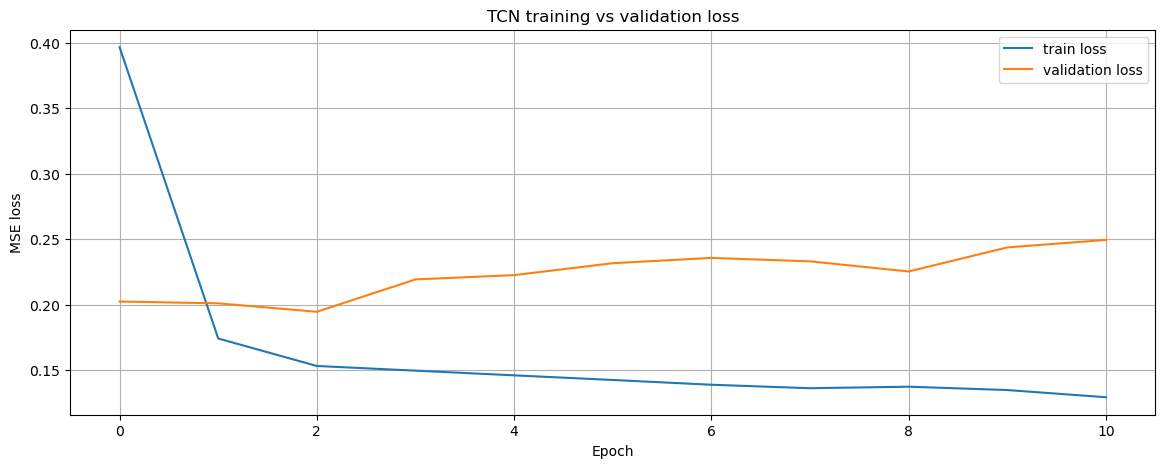

In [18]:
def tcn_block(x, filters, kernel_size, dilation_rate, dropout):
    shortcut = x
    x = layers.Conv1D(filters, kernel_size, padding="causal", dilation_rate=dilation_rate, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters, kernel_size, padding="causal", dilation_rate=dilation_rate, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    
    #match dimensions for residual connection if needed
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding="same")(shortcut)
    return layers.Add()([shortcut, x])


def build_tcn(input_shape, filters=64, kernel_size=3, dropout=0.2, lr=0.001):
    inp = layers.Input(shape=input_shape)
    x = inp
    for dilation in [1, 2, 4, 8]:
        x = tcn_block(x, filters=filters, kernel_size=kernel_size, dilation_rate=dilation, dropout=dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation="relu")(x)
    out = layers.Dense(1)(x)
    model = models.Model(inp, out)
    model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss="mse")
    return model

tcn_model = build_tcn(X_train_seq.shape[1:], filters=64, kernel_size=3, dropout=0.2, lr=0.001)
es = callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

tcn_history = tcn_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=60,
    batch_size=32,
    verbose=1,
    callbacks=[es]
)

plot_history(tcn_history, "TCN training vs validation loss")

Again seems it's very fast at learning then it starts overfitting even sooner than previous model

In [19]:
tcn_pred_scaled = tcn_model.predict(X_test_seq).ravel()
tcn_pred = inverse_y(tcn_pred_scaled)

tcn_metrics = regression_metrics(y_test_true, tcn_pred, "TCN")
all_forecast_metrics = pd.concat([lstm_metrics, tcn_metrics], ignore_index=True)
all_forecast_metrics

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


,Model,MAE,RMSE,MAPE (%)
0,LSTM,1489.158346,2377.822480,42.572299
1,TCN,1737.156870,2512.564718,53.080347


The LSTM model performed a bit better overall, with lower MAE, RMSE and MAPE values compared to TCN. It seems the simpler LSTM architecture was able to capture the daily solar production patterns more effectively on this dataset🤔

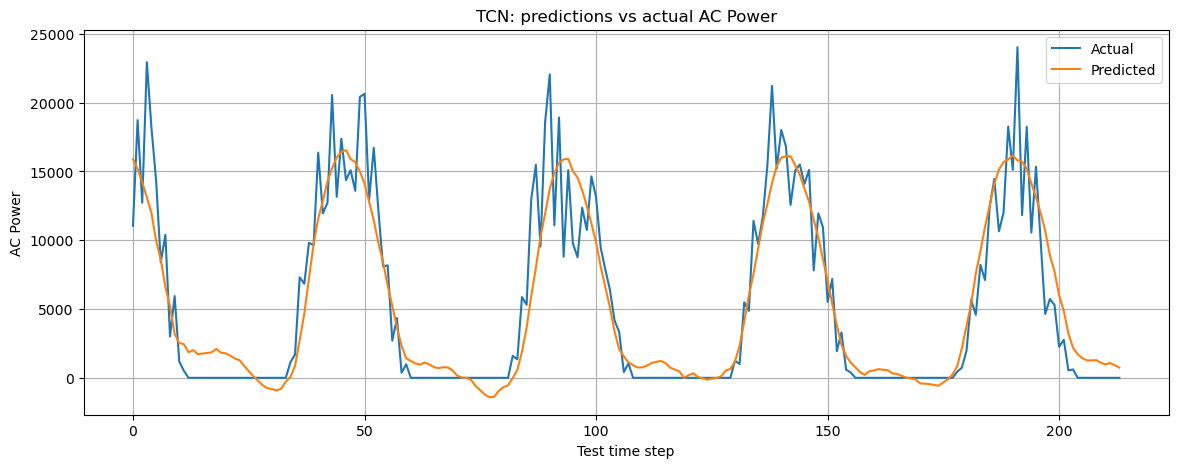

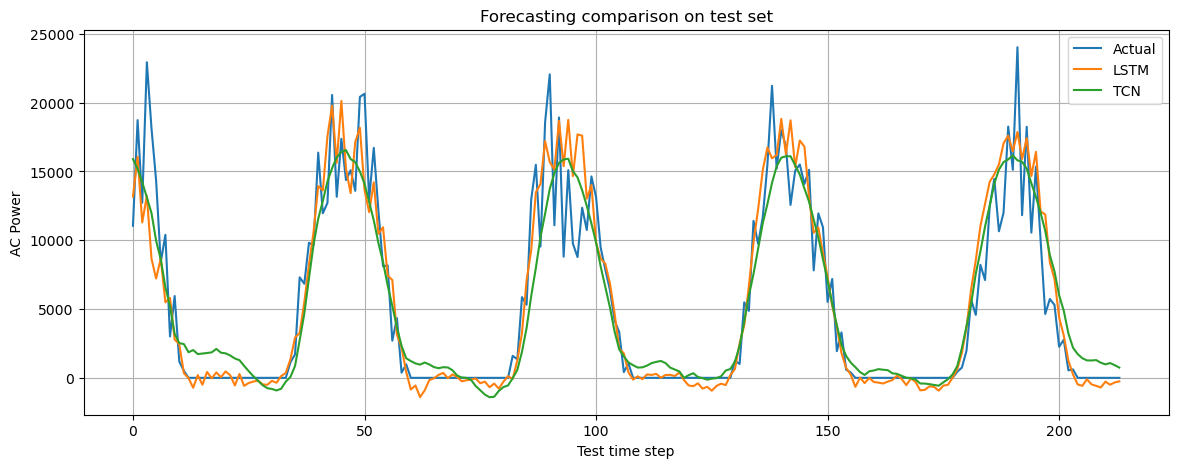

In [20]:
plot_predictions(y_test_true, tcn_pred, "TCN: predictions vs actual AC Power")

plt.figure()
plt.plot(y_test_true[:250], label="Actual")
plt.plot(lstm_pred[:250], label="LSTM")
plt.plot(tcn_pred[:250], label="TCN")
plt.title("Forecasting comparison on test set")
plt.xlabel("Test time step")
plt.ylabel("AC Power")
plt.legend()
plt.show()

Seems to be obvious that here LSTM is better. But given this dataset isn't huge, still inconclusive to make definitive conclusions about solar power generation prediction.

## 10. Anomaly detection setup

The dataset does not provide true anomaly labels, so we have to define a practical rule to create pseudo labels for evaluation.

Will mark a point as outlier when:

- irradiation is high enoguh, meaning sunlight is available
- but AC power is much lower than expected compared to the normal irradiation power relationship

This follows the dataset suggestion: solar panel degradation or sensor/panel problems can appear when irradiation is high but power output is low

In [37]:
anom = hourly.copy().sort_values(["PLANT", "datetime"]).reset_index(drop=True)

#normalize inside each plant so Plant 1 and Plant 2 are comparable
anom["AC_POWER_norm"] = anom.groupby("PLANT")["AC_POWER"].transform(lambda x: x / (x.max() + 1e-9))
anom["IRRADIATION_norm"] = anom.groupby("PLANT")["IRRADIATION"].transform(lambda x: x / (x.max() + 1e-9))

#remove nighttime / very low irradiation points before deciding thresholds
#otherwise AC_POWER quantile becomes 0 because many night values are zero
daytime_mask = anom["IRRADIATION_norm"] > 0.05
daytime = anom[daytime_mask].copy()

#rule based pseudo labels using quantiles only on daytime data
irr_high_threshold = daytime["IRRADIATION_norm"].quantile(0.70)
power_low_threshold = daytime["AC_POWER_norm"].quantile(0.25)

#start with everything as non-anomaly
anom["rule_anomaly"] = 0

#anomaly = high irradiation but low power, only checked during daytime
anom.loc[daytime_mask, "rule_anomaly"] = (
    (anom.loc[daytime_mask, "IRRADIATION_norm"] > irr_high_threshold) &
    (anom.loc[daytime_mask, "AC_POWER_norm"] < power_low_threshold)
).astype(int)

print("Irradiation high threshold:", irr_high_threshold)
print("Power low threshold:", power_low_threshold)
print("Rule anomalies:", anom["rule_anomaly"].sum(), "out of", len(anom))

anom[["datetime", "PLANT", "AC_POWER", "IRRADIATION", "AC_POWER_norm", "IRRADIATION_norm", "rule_anomaly"]].head()

Irradiation high threshold: 0.6692448007900365
Power low threshold: 0.2787809880074012
Rule anomalies: 5 out of 1632


,datetime,PLANT,AC_POWER,IRRADIATION,AC_POWER_norm,IRRADIATION_norm,rule_anomaly
0,2020-05-15 00:00:00,Plant_1,0.0,0.0,0.0,0.0,0
1,2020-05-15 01:00:00,Plant_1,0.0,0.0,0.0,0.0,0
2,2020-05-15 02:00:00,Plant_1,0.0,0.0,0.0,0.0,0
3,2020-05-15 03:00:00,Plant_1,0.0,0.0,0.0,0.0,0
4,2020-05-15 04:00:00,Plant_1,0.0,0.0,0.0,0.0,0


## 11. Traditional ML anomaly detection: Isolation Forest

Isolation Forest detects anomalies by finding points that are easier to isolate from the rest of the data.
Will use features related to power, weather, and the mismatch between irradiation and power

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def detection_metrics(y_true, y_pred, name):
    return pd.DataFrame({
        "Model": [name],
        "Accuracy": [accuracy_score(y_true, y_pred)],
        "Precision": [precision_score(y_true, y_pred, zero_division=0)],
        "Recall": [recall_score(y_true, y_pred, zero_division=0)],
        "F1": [f1_score(y_true, y_pred, zero_division=0)]
    })

anom["power_irradiation_gap"] = anom["IRRADIATION_norm"] - anom["AC_POWER_norm"]
anom["temp_gap"] = anom["MODULE_TEMPERATURE"] - anom["AMBIENT_TEMPERATURE"]

#focus only on daytime, because night values dominate and are not useful for this anomaly definition
anom_day = anom[anom["IRRADIATION_norm"] > 0.05].copy().reset_index(drop=True)

anomaly_features = [
    "AC_POWER_norm",
    "IRRADIATION_norm",
    "power_irradiation_gap",
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "temp_gap"
]

anom_day = anom_day.dropna(subset=anomaly_features).reset_index(drop=True)

split_idx = int(len(anom_day) * 0.70)
anom_train = anom_day.iloc[:split_idx].copy()
anom_test = anom_day.iloc[split_idx:].copy()

anom_scaler = StandardScaler()
X_anom_train = anom_scaler.fit_transform(anom_train[anomaly_features])
X_anom_test = anom_scaler.transform(anom_test[anomaly_features])

# keep contamination close to rule anomaly rate, but not too tiny
contamination = max(0.02, anom_train["rule_anomaly"].mean())

iso = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    random_state=SEED
)

iso.fit(X_anom_train)

anom_test["iso_anomaly"] = (iso.predict(X_anom_test) == -1).astype(int)

iso_metrics = detection_metrics(
    anom_test["rule_anomaly"],
    anom_test["iso_anomaly"],
    "Isolation Forest"
)

iso_metrics

,Model,Accuracy,Precision,Recall,F1
0,Isolation Forest,0.991342,0.333333,1.0,0.5


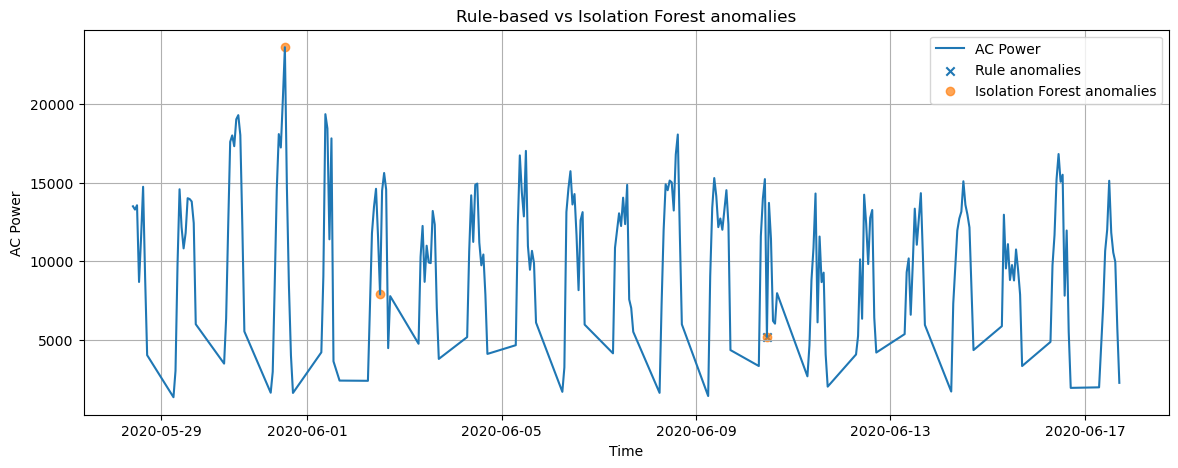

In [47]:
plt.figure(figsize=(14, 5))
plt.plot(anom_test["datetime"], anom_test["AC_POWER"], label="AC Power")

rule_points = anom_test[anom_test["rule_anomaly"] == 1]
iso_points = anom_test[anom_test["iso_anomaly"] == 1]

plt.scatter(rule_points["datetime"], rule_points["AC_POWER"], label="Rule anomalies", marker="x")
plt.scatter(iso_points["datetime"], iso_points["AC_POWER"], label="Isolation Forest anomalies", alpha=0.7)

plt.title("Rule-based vs Isolation Forest anomalies")
plt.xlabel("Time")
plt.ylabel("AC Power")
plt.legend()
plt.show()

The Isolation Forest managed to detect some of the same suspicious points as the rule based approach, especially during periods where AC power behaves weirdly compared to the normal daily pattern. However, it also seems to detect a few additional anomalies, which shows that the model is learning more general abnormal behavior instead of only following the manually defined rule.

## 12. Deep learning anomaly detection: Autoencoder

For the DL based anomaly detector, I'll use an autoencoder.
The autoencoder learns to reconstruct normal patterns. If a point has a high reconstruction error, it means the point does not look like what the model learned as normal.

I train it mostly on normal data from the training split according to the above defined definition. Then I use reconstruction error on the test split.

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.8549 - val_loss: 1.4382
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8035 - val_loss: 1.3933
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7516 - val_loss: 1.3472
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6906 - val_loss: 1.2932
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6192 - val_loss: 1.2323
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5446 - val_loss: 1.1690
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4744 - val_loss: 1.1057
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4149 - val_loss: 1.0431
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3654 - val_loss: 0.9824
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3229 - val_loss: 0.9241
Epoch 11/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2849 - val_loss: 0.8699
Epoch 12/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.

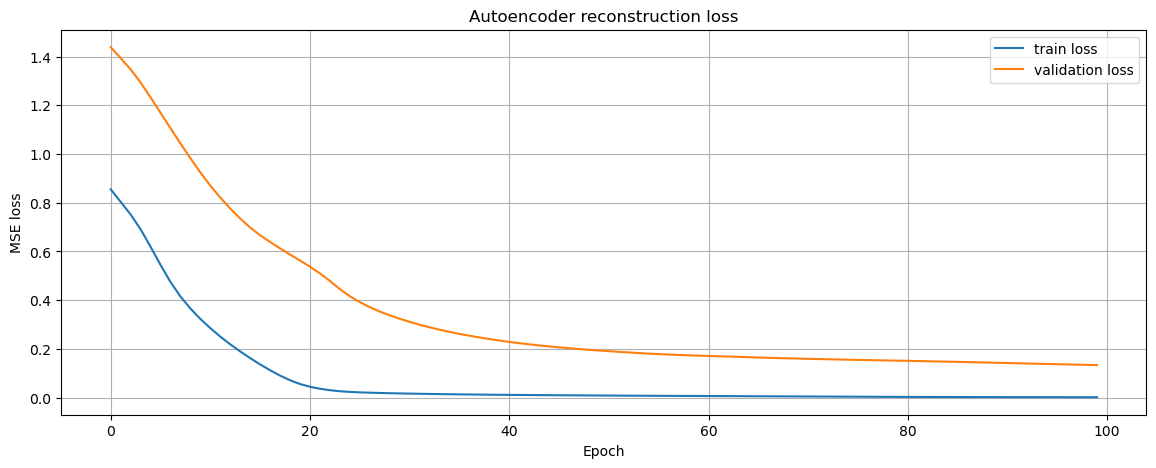

In [49]:
#train autoencoder only on normal points according to the rule label
normal_train = anom_train[anom_train["rule_anomaly"] == 0]
X_ae_train = anom_scaler.transform(normal_train[anomaly_features])
X_ae_test = X_anom_test

input_dim = X_ae_train.shape[1]

ae = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(input_dim)
])

ae.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss="mse")
es = callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

ae_history = ae.fit(
    X_ae_train, X_ae_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=[es]
)

plot_history(ae_history, "Autoencoder reconstruction loss")

We can see both train and validation loss dropping fast in the first epochs. After around 20 epochs the validation loss starts stabilizing while train loss keeps getting very close to zero, which hints at slight overfitting but still good enough generalization nonetheless.

In [50]:
recon = ae.predict(X_ae_test)
reconstruction_error = np.mean(np.square(X_ae_test - recon), axis=1)

#threshold chosen from train reconstruction error; top 5% highest errors are treated as anomalies
train_recon = ae.predict(X_ae_train)
train_error = np.mean(np.square(X_ae_train - train_recon), axis=1)
threshold = np.quantile(train_error, 0.95)

anom_test["ae_error"] = reconstruction_error
anom_test["ae_anomaly"] = (anom_test["ae_error"] > threshold).astype(int)

print("Autoencoder anomaly threshold:", threshold)
anom_test[["datetime", "PLANT", "rule_anomaly", "ae_error", "ae_anomaly"]].head()

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Autoencoder anomaly threshold: 0.08303351710450955


,datetime,PLANT,rule_anomaly,ae_error,ae_anomaly
537,2020-05-28 10:00:00,Plant_2,0,0.200365,1
538,2020-05-28 11:00:00,Plant_2,0,0.289909,1
539,2020-05-28 12:00:00,Plant_2,0,0.199520,1
540,2020-05-28 13:00:00,Plant_2,0,1.284706,1
541,2020-05-28 14:00:00,Plant_2,0,0.319651,1


In [51]:
ae_metrics = detection_metrics(anom_test["rule_anomaly"], anom_test["ae_anomaly"], "Autoencoder")
all_anomaly_metrics = pd.concat([iso_metrics, ae_metrics], ignore_index=True)
all_anomaly_metrics

,Model,Accuracy,Precision,Recall,F1
0,Isolation Forest,0.991342,0.333333,1.0,0.50
1,Autoencoder,0.835498,0.025641,1.0,0.05


We see that isolation forest performed really well on finding all anomalies but also there are about 2 out of 3 times false positives. But autoencoder performed much worse in this regard, even though they both found all anomalies, autoencoder really flagged way too many instances as anomalies even though they weren't, from the extremely low precision metric.

In [54]:
def plot_anomalies(df_plot, anomaly_col, title):
    plt.figure()
    plt.plot(df_plot["datetime"], df_plot["AC_POWER"], label="AC Power")
    points = df_plot[df_plot[anomaly_col] == 1]
    plt.scatter(points["datetime"], points["AC_POWER"], label="Detected anomalies")
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("AC Power")
    plt.legend()
    plt.show()

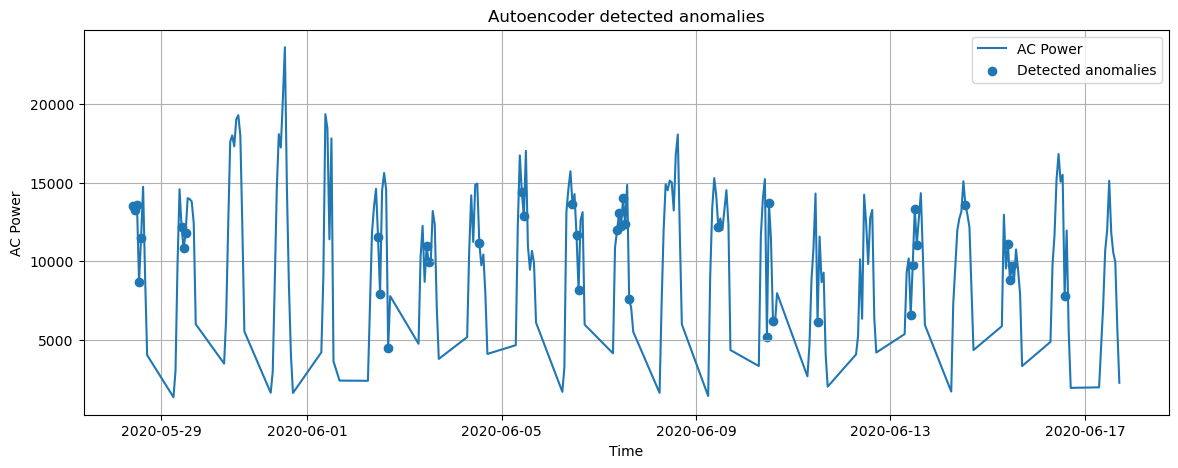

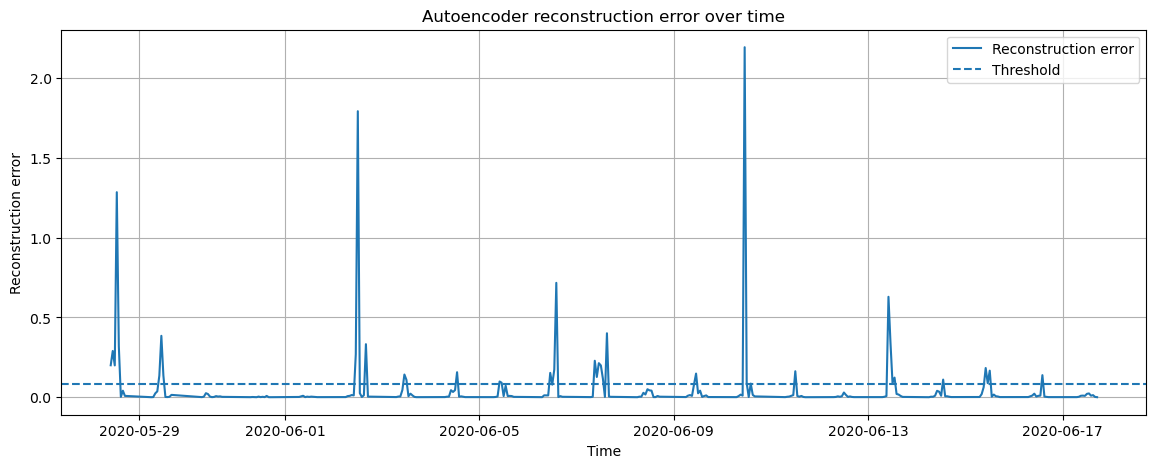

In [55]:
plot_anomalies(anom_test, "ae_anomaly", "Autoencoder detected anomalies")

plt.figure()
plt.plot(anom_test["datetime"], anom_test["ae_error"], label="Reconstruction error")
plt.axhline(threshold, linestyle="--", label="Threshold")
plt.title("Autoencoder reconstruction error over time")
plt.xlabel("Time")
plt.ylabel("Reconstruction error")
plt.legend()
plt.show()

In [56]:
print("Forecasting metrics:")
display(all_forecast_metrics)

print("Anomaly detection metrics:")
display(all_anomaly_metrics)

Forecasting metrics:


,Model,MAE,RMSE,MAPE (%)
0,LSTM,1489.158346,2377.822480,42.572299
1,TCN,1737.156870,2512.564718,53.080347


Anomaly detection metrics:


,Model,Accuracy,Precision,Recall,F1
0,Isolation Forest,0.991342,0.333333,1.0,0.50
1,Autoencoder,0.835498,0.025641,1.0,0.05
